# Misurazione della rilevanza topologica

### Obiettivo
Misurare l'importanza della struttura topologica del grafo nella classificazione.

### Problema
Nei test precedenti, i modelli GNN avevano prestazioni sovrastate da quelle del MLP.
La motivazione è data dall'uso del modello: una GNN, tramite i layer di message passing, impara a propagare in modo significativo le informazioni attraverso gli archi del grafo. L'input dovrebbe quindi essere un altro grafo sul quale applicare gli operatori di message passing con gli stessi pesi appresi in fase di training.
Nel caso (degenere) in cui si passi un grafo composto da un solo nodo, la GNN regredisce ad un MLP come si può vedere dalla formula:
\begin{equation}
\mathbf{h}_v^{(k)} = \text{UPDATE}^{(k)}\left( \mathbf{h}_v^{(k-1)}, \text{AGGREGATE}^{(k)}\left( \left\{ \mathbf{h}_u^{(k-1)} \mid u \in \mathcal{N}(v) \right\} \right) \right)
\end{equation}
La funzione di aggregazione diventa nulla quando $\mathcal{N}(v) = \emptyset$ quindi:
\begin{equation}
\mathbf{h}_v^{(k)} = \text{UPDATE}^{(k)}( \mathbf{h}_v^{(k-1)}, 0)
\end{equation}

In molte architetture (GraphSAGE, GCN, ...) la funzione di UPDATE è un MLP

### Il test - Rewiring
Vista l'ambiguità, sarebbe utile misurare a priori se la topologia può aiutare nell'inferenza. Posso farlo con un test di rewiring: scambio casualmente gli archi da coppie di nodi effettivamente distruggendo la topologia.
Il rewiring può essere degree preserving o meno.

NOTA BENE: questo test ha senso in un setting transductive in quanto nel setting inductive faccio inferenza su un nodo isolato, tornando al problema della sezione precedente.

COSA MI ASPETTO: Le prestazioni del modello addestrato sul grafo rewired devono crollare, nel caso migliore il modello "capisce" che la topologia non aiuta nella predizione e assegna dei pesi bassi alla propagazione dei messaggi, avvicinandosi ad un MLP. Le prestazioni del modello GNN addestrato su grafo normale dovrebbero essere molto più alte. 

### Definizione della pipeline e caricamento dataset

In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
from data_pipeline import *
import torch_geometric.transforms as T


pre_transform = T.Compose([
    MarkCommonNodes(edge_types=('AD','PD')),
    DuplicateCommonNodesAndRelabel(suffix_ad='_AD', suffix_pd='_PD'),
    ReindexConsecutive(),
    MergeRelationsToHomogeneous(merge=['AD','PD'], edge_attr_reduce='sum'),
    FilterSmallConnectedComponents(topk=2)
])

ds = NeuroDegAnc2VecDataset(root='data', pre_transform=pre_transform, force_reload=True)
data = ds[0]

Processing...
Done!


### Split dataset e definizione del training process
Esperimento in condizioni normali con setting inductive e transductive

In [9]:
%load_ext autoreload
%autoreload 2


from training_tools.splitter import StratifiedSplitterWithTestHoldout
from training_tools.task import TaskBinaryNodeClassification
from training_tools.trainer import Trainer
from training_tools.validation import CrossValidator
from training_tools.evaluation import Evaluator

from models import GCN, GCN_Sage, MLP
import pprint, tqdm

def compare_models_over_repeats(
    data,                   # Data
    model_factories,           # [factory_A, factory_B, ...]
    splitter_ctor,             # lambda seed, mode: StratifiedNestedSplitter(...)
    task, trainer, mode="transductive",
    n = 10
):
    seeds=list(range(n))
    # metriche per modello: dict[name] -> list of per-run test F1
    results = {i: [] for i in range(len(model_factories))}

    with tqdm.tqdm(total=len(seeds), desc="Training Progress", unit="iteration") as pbar:
        for seed in seeds:
            splitter = splitter_ctor(seed, mode)
            parts = splitter.split(data)

            for idx, factory in enumerate(model_factories):
                cv = CrossValidator(trainer=trainer, model_factory=factory, mode=mode, select_by="f1")
                artifacts, summary = cv.run(task, data, parts)

                evaluator = Evaluator(model_factory=factory, mode=mode)
                test_metrics = evaluator.evaluate(task, data, parts, artifacts["best_state"])
                results[idx].append(test_metrics["f1"])  # metrica primaria
            pbar.update(1)

    return results

model_factories = [
    lambda : GCN_Sage(in_channels=data.x.size(1), hidden_channels=64, out_channels=1, num_layers=2, dropout=0),
    lambda : GCN_Sage(in_channels=data.x.size(1), hidden_channels=64, out_channels=1, num_layers=2, dropout=0, head_type="mlp"),
    lambda : GCN_Sage(in_channels=data.x.size(1), hidden_channels=64, out_channels=1, num_layers=3, dropout=0),
    lambda : GCN(in_channels=data.x.size(1), hidden_channels=64, out_channels=1, dropout=0),
    lambda : MLP(in_channels=data.x.size(1), hidden_channels=64, out_channels=1, dropout=0)
]


splitter_ctor = lambda seed, mode: StratifiedSplitterWithTestHoldout(test_size=0.1, n_splits=5, seed=seed, mode=mode)

task    = TaskBinaryNodeClassification(threshold=0.5, pos_weight=None)
trainer = Trainer(lr=1e-3, weight_decay=5e-4, max_epochs=50, patience=10)

results = dict()

results['inductive']    = compare_models_over_repeats(data, model_factories, splitter_ctor, task, trainer, mode='inductive', n=1)
# results['transductive'] = compare_models_over_repeats(data, model_factories, splitter_ctor, task, trainer, mode='transductive', n=20)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Training Progress: 100%|██████████| 1/1 [00:05<00:00,  5.89s/iteration]


### Plot
Qui mi aspetto di vedere che in modalità transductive GNN > MLP ma in modalità inductive GNN ~ MLP

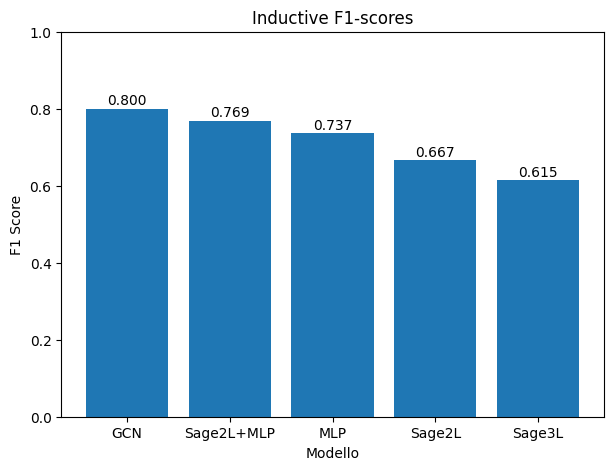

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# model_names = [model().__class__.__name__ for model in model_factories]
model_names = ["Sage2L", "Sage2L+MLP", "Sage3L", "GCN", "MLP"]

# formatted_transductive  = dict(zip(model_names, [np.array(res).mean() for _, res in results['transductive'].items()]))
formatted_inductive     = dict(zip(model_names, [np.array(res).mean() for _, res in results['inductive'].items()]))


def plot_f1(formatted, title):
    sorted_formatted = dict(sorted(formatted.items(), key=lambda x: x[1], reverse=True))

    names = list(sorted_formatted.keys())
    values = list(sorted_formatted.values())

    plt.figure(figsize=(7, 5))
    plt.bar(names, values)
    plt.title(title)
    plt.ylabel("F1 Score")
    plt.xlabel("Modello")
    plt.ylim(0, 1)  # opzionale

    for i, v in enumerate(values):
        plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

    plt.show()

# plot_f1(formatted_transductive  , title='Trasductive F1-scores')
plot_f1(formatted_inductive     , title='Inductive F1-scores')


### Test di Rewiring

Qui verranno fatti tre addestramenti in modalità transductive:
1. GCN (fatto come al solito)
2. GCN su grafo rewired
3. MLP



Training GCN on original and rewired graphs: 100%|██████████| 200/200 [10:16<00:00,  3.08s/trainings]


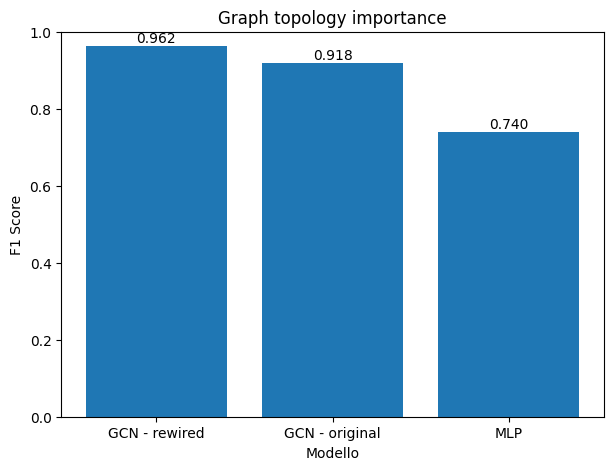

In [14]:
from graph_data_manipulation import *

g_rewired = rewire_non_degree_preserving_stratified(
    data,
    seed=4
)

mode = 'transductive'
seed = 4
factory = lambda : GCN(in_channels=data.x.size(1), hidden_channels=64, out_channels=1, dropout=0)

task    = TaskBinaryNodeClassification(threshold=0.5, pos_weight=None)
trainer = Trainer(lr=1e-3, weight_decay=5e-4, max_epochs=50, patience=10)

n = 200

test_metrics_mlp = compare_models_over_repeats(
    data, 
    [lambda : MLP(in_channels=data.x.size(1), hidden_channels=64, out_channels=1, dropout=0)], 
    splitter_ctor, task, trainer, mode='transductive', n=n)

test_metrics = [] 
test_metrics_rew = []

for x in tqdm.tqdm(range(n), desc="Training GCN on original and rewired graphs", unit="trainings"):
    splitter = StratifiedSplitterWithTestHoldout(test_size=0.1, n_splits=5, seed=x, mode=mode)
    parts = splitter.split(data)
    rewired_parts = splitter.split(g_rewired)

    cv = CrossValidator(trainer=trainer, model_factory=factory, mode=mode, select_by="f1")
    cv_rew = CrossValidator(trainer=trainer, model_factory=factory, mode=mode, select_by="f1")
    artifacts, summary = cv.run(task, data, parts)
    artifacts_rew, summary_rew = cv_rew.run(task, g_rewired, rewired_parts)

    evaluator = Evaluator(model_factory=factory, mode=mode)
    test_metrics.append(evaluator.evaluate(task, data, parts, artifacts["best_state"])['f1'])
    test_metrics_rew.append(evaluator.evaluate(task, g_rewired, rewired_parts, artifacts_rew["best_state"])['f1'])

formatted = {
    'GCN - original': np.array(test_metrics).mean(),
    'GCN - rewired' : np.array(test_metrics_rew).mean(),
    'MLP': np.array(list(test_metrics_mlp.values())).mean()
}
plot_f1(formatted, title='Graph topology importance')

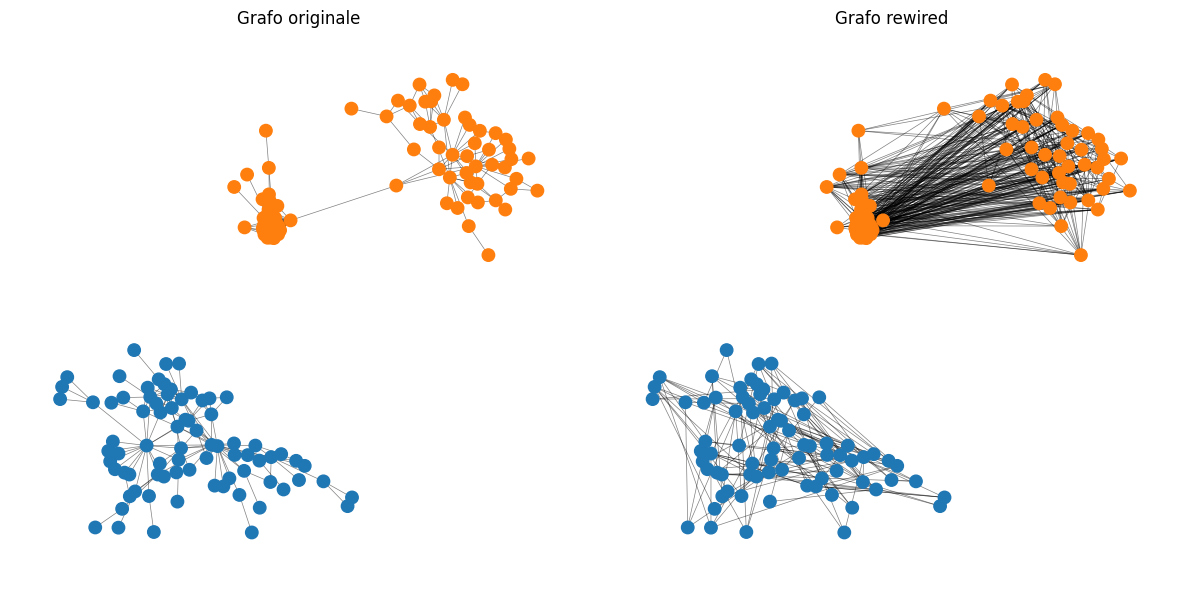

In [ ]:
import torch
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx
from torch_geometric.data import Data


def plot_graph_before_after(
    data: "Data",
    data_rewired: "Data",
    *,
    node_size: int = 80,
    alpha_edges: float = 0.5,
    seed_layout: int = 42,
):
    """
    Plotta il grafo originale e quello rewired affiancati, usando lo stesso layout.

    - Colore nodi = classe (y=0, y=1).
    - Stesso posizionamento (spring layout) per confronto visivo.

    Parametri
    ---------
    data : Data
        Grafo originale PyG.
    data_rewired : Data
        Grafo dopo rewiring (stesso numero di nodi, stessi indici).
    node_size : int
        Dimensione dei nodi nel plot.
    alpha_edges : float
        Trasparenza degli archi.
    seed_layout : int
        Seed per il layout spring di NetworkX (riproducibilità).
    """
    assert data.num_nodes == data_rewired.num_nodes, "I due grafi devono avere lo stesso numero di nodi"

    # converte a NetworkX (non orientato per la visualizzazione)
    G_real = to_networkx(data, to_undirected=True, remove_self_loops=True)
    G_rew  = to_networkx(data_rewired, to_undirected=True, remove_self_loops=True)

    # layout unico per entrambi
    pos = nx.spring_layout(G_real, seed=seed_layout)

    # colori nodi in base a y
    y = data.y.detach().cpu().numpy()
    # mappa semplice: 0 -> blu, 1 -> arancione, altro -> grigio
    def _color(c):
        if c == 0:
            return "tab:blue"
        elif c == 1:
            return "tab:orange"
        else:
            return "tab:gray"

    node_colors = [_color(int(c)) for c in y]

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # --- grafo originale ---
    ax = axes[0]
    nx.draw_networkx_nodes(
        G_real, pos,
        node_color=node_colors,
        node_size=node_size,
        ax=ax
    )
    nx.draw_networkx_edges(
        G_real, pos,
        alpha=alpha_edges,
        width=0.5,
        ax=ax
    )
    ax.set_title("Grafo originale")
    ax.axis("off")

    # --- grafo rewired ---
    ax = axes[1]
    nx.draw_networkx_nodes(
        G_rew, pos,
        node_color=node_colors,  # stesse classi, stessi colori
        node_size=node_size,
        ax=ax
    )
    nx.draw_networkx_edges(
        G_rew, pos,
        alpha=alpha_edges,
        width=0.5,
        ax=ax
    )
    ax.set_title("Grafo rewired")
    ax.axis("off")

    plt.tight_layout()
    plt.show()


plot_graph_before_after(data, g_rewired)


In [17]:
import torch

def check_undirected(edge_index, num_nodes=None):
    """
    edge_index: LongTensor [2, E]
    num_nodes: opzionale, se None viene stimato da edge_index

    Ritorna:
        is_undirected (bool)
        directed_edges (LongTensor [2, K]): archi che non hanno il reciproco
    """
    if num_nodes is None:
        num_nodes = int(edge_index.max()) + 1

    # [E, 2]
    pairs = edge_index.t()

    # codifica (u, v) → u * N + v per fare membership check veloce
    lin = pairs[:, 0] * num_nodes + pairs[:, 1]
    lin_rev = pairs[:, 1] * num_nodes + pairs[:, 0]

    # se hai PyTorch recente puoi usare torch.isin, altrimenti vedi versione sotto
    has_reverse = torch.isin(lin, lin_rev)
    directed_mask = ~has_reverse

    directed_edges = edge_index[:, directed_mask]
    is_undirected = directed_edges.numel() == 0

    if is_undirected:
        print("✅ Il grafo è già non orientato (edge_index è simmetrico).")
    else:
        print("⚠️  Il grafo NON è completamente non orientato. Archi solo diretti:")
        print(directed_edges)

    return is_undirected, directed_edges

b, e = check_undirected(data.edge_index)
print(e)

⚠️  Il grafo NON è completamente non orientato. Archi solo diretti:
tensor([[132,  29,  29,  ...,  63,   7,   7],
        [ 29, 148, 146,  ...,  19,  73,  63]])
tensor([[132,  29,  29,  ...,  63,   7,   7],
        [ 29, 148, 146,  ...,  19,  73,  63]])
